# MI 实验可视化

处理 `record/4-LIF/` 和 `record/5-LIF/` 下的日志：

- **柱状图**：每个拓扑最后一个 epoch 的 I(Z;X) / I(Z;Y)，按 LIF2HH 公式 (26) 每个 seed 内部 L2 归一，再跨 seed 求均值（4-LIF / 5-LIF 分别画，IZX / IZY 分开画，带 std 误差线）
- **折线图**：用与柱状图**同一个** per-seed L2 归一化结果（每个 seed 一个固定的分母，由该 seed 全部 model 的最后 epoch 值算 L2），对所有 epoch 跨 seed 求均值，画 I(Z;X) / I(Z;Y) 随 epoch 的演变（无误差线）

**关键点**：柱状图和折线图共用同一组归一化数据。分母在每个 seed 内部是固定的（用该 seed 全部 model 的最后 epoch 值算一次 L2），所以 epoch 间的归一化值可以直接比大小，y 轴尺度在 epoch 间一致。

In [6]:
import os
import re
import math
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

RECORD_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__') if '__file__' in dir() else '.'), 'record')
GROUPS = ['4-LIF', '5-LIF']

TEST_RE = re.compile(r'e:(\d+)\s+IZY:([-\d.]+)\s+IZX:([-\d.]+)')
LOG_NAME_RE = re.compile(r'^(?P<model>.+?)_seed(?P<seed>\d+)\.log$')

In [7]:
def parse_all_epochs(path):
    """Return list of (epoch, IZY, IZX) sorted by epoch."""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            m = TEST_RE.search(line)
            if m:
                rows.append((int(m.group(1)), float(m.group(2)), float(m.group(3))))
    rows.sort(key=lambda x: x[0])
    return rows


def load_group(group):
    """Return dict: {model: {seed: [(epoch, izy, izx), ...]}}."""
    group_dir = os.path.join(RECORD_DIR, group)
    data = defaultdict(dict)
    for fname in sorted(os.listdir(group_dir)):
        m = LOG_NAME_RE.match(fname)
        if not m:
            continue
        model = m.group('model')
        seed = int(m.group('seed'))
        data[model][seed] = parse_all_epochs(os.path.join(group_dir, fname))
    return data


data = {g: load_group(g) for g in GROUPS}
for g in GROUPS:
    print(f'{g}:')
    for m, seeds in data[g].items():
        n_eps = len(next(iter(seeds.values())))
        print(f'  {m}: {len(seeds)} seeds, {n_eps} epochs')

4-LIF:
  HH: 4 seeds, 40 epochs
  LIF_1_1_1_1: 4 seeds, 40 epochs
  LIF_1_2_1: 4 seeds, 40 epochs
  LIF_1_3: 4 seeds, 40 epochs
  LIF_2_2: 4 seeds, 40 epochs
  LIF_hh: 4 seeds, 40 epochs
  LIF: 4 seeds, 40 epochs
5-LIF:
  LIF_1_1_1_1_1: 3 seeds, 40 epochs
  LIF_1_1_2_1: 3 seeds, 40 epochs
  LIF_1_1_3: 3 seeds, 40 epochs
  LIF_1_2_2: 3 seeds, 40 epochs
  LIF_1_3_1: 3 seeds, 40 epochs
  LIF_1_4: 3 seeds, 40 epochs


In [8]:
def normalize_per_seed_fixed_l2(data_group):
    """Per-seed L2 normalize, with ONE fixed L2 norm per seed.

    For each seed, the L2 denominator is computed from the last-epoch values
    of ALL models in that seed (per LIF2HH eq. 26). The same denominator is
    then used to normalize IZY/IZX at every epoch, so the y-axis scale is
    consistent across epochs.

    Returns: {model: {seed: [(epoch, izy_norm, izx_norm), ...]}}
    """
    all_seeds = set()
    for seeds in data_group.values():
        all_seeds.update(seeds.keys())

    seed_izy_l2, seed_izx_l2 = {}, {}
    for seed in all_seeds:
        izy_vals, izx_vals = [], []
        for model, seeds in data_group.items():
            if seed in seeds:
                _, last_izy, last_izx = seeds[seed][-1]
                izy_vals.append(last_izy)
                izx_vals.append(last_izx)
        seed_izy_l2[seed] = math.sqrt(sum(v * v for v in izy_vals)) or 1.0
        seed_izx_l2[seed] = math.sqrt(sum(v * v for v in izx_vals)) or 1.0

    normed = defaultdict(dict)
    for model, seeds in data_group.items():
        for seed, rows in seeds.items():
            izy_l2 = seed_izy_l2[seed]
            izx_l2 = seed_izx_l2[seed]
            normed[model][seed] = [
                (ep, izy / izy_l2, izx / izx_l2) for ep, izy, izx in rows
            ]
    return normed

## 柱状图：最后一 epoch 的 I(Z;X) / I(Z;Y)（per-seed L2 归一，跨 seed 求 mean ± std）

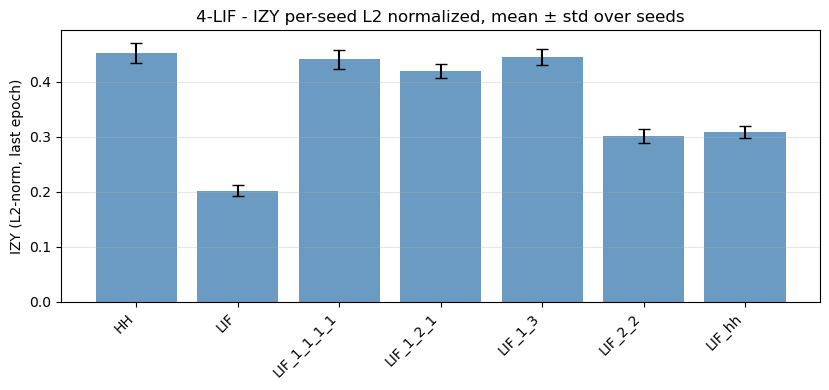

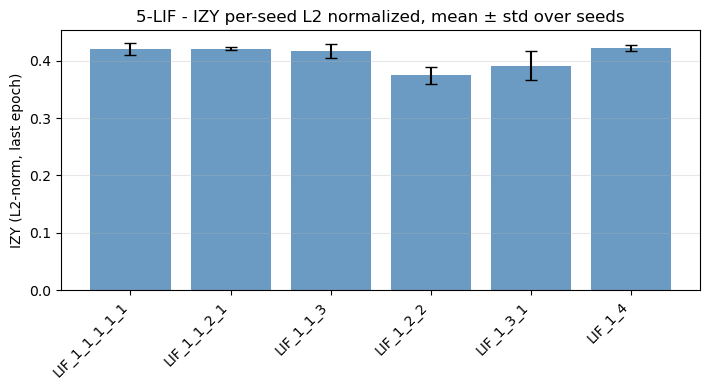

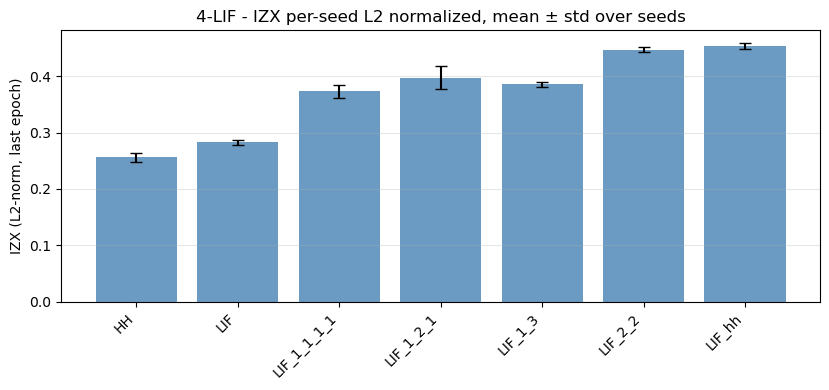

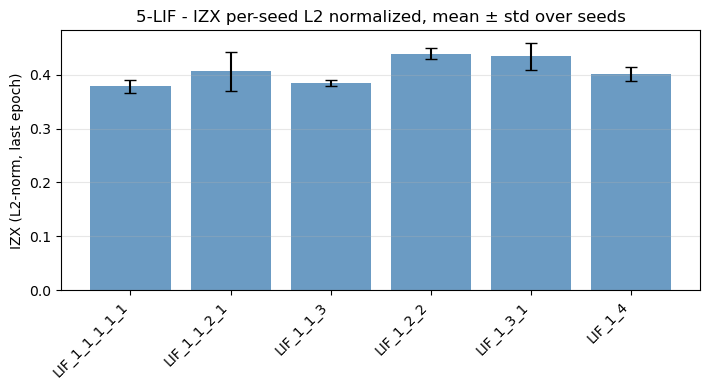

In [9]:
for metric_name, metric_idx in [('IZY', 1), ('IZX', 2)]:
    for group in GROUPS:
        normed = normalize_per_seed_fixed_l2(data[group])
        models = sorted(normed.keys())
        means, stds = [], []
        for m in models:
            vals = [rows[-1][metric_idx] for rows in normed[m].values()]
            means.append(np.mean(vals)); stds.append(np.std(vals))
        fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(models)), 4))
        x = np.arange(len(models))
        ax.bar(x, means, yerr=stds, capsize=4, color='steelblue', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(f'{metric_name} (L2-norm, last epoch)')
        ax.set_title(f'{group} - {metric_name} per-seed L2 normalized, mean ± std over seeds')
        ax.grid(axis='y', alpha=0.3)
        fig.tight_layout(); plt.show()

## 折线图：每 epoch I(Z;X) / I(Z;Y) 演变（与柱状图共用同一组归一化数据）

柱状图和折线图共用 `normalize_per_seed_fixed_l2` 的结果，所以 epoch 间 y 轴尺度一致，可直接比较。

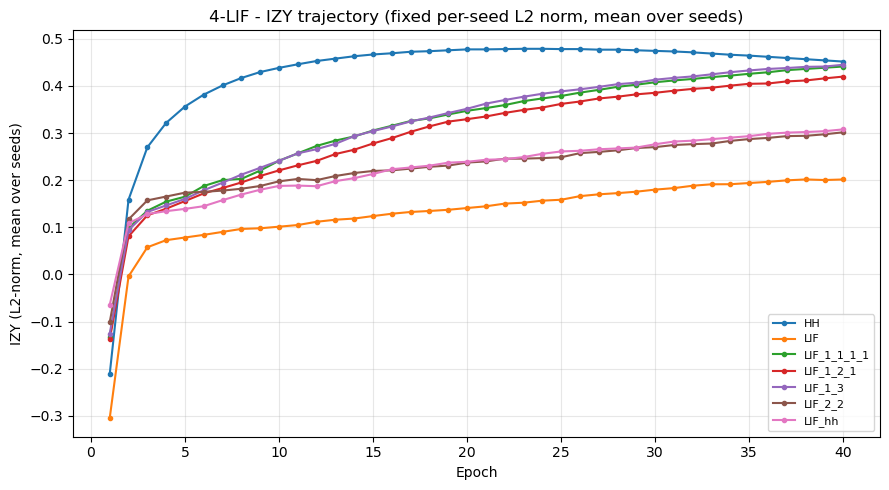

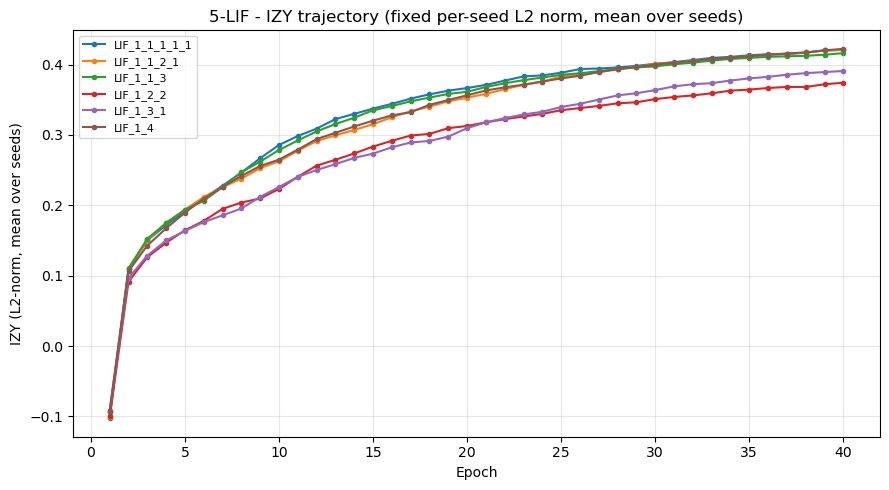

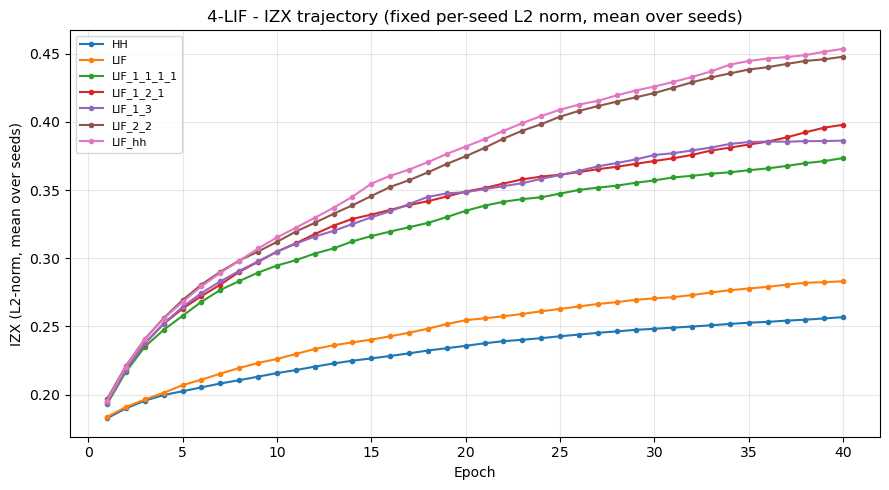

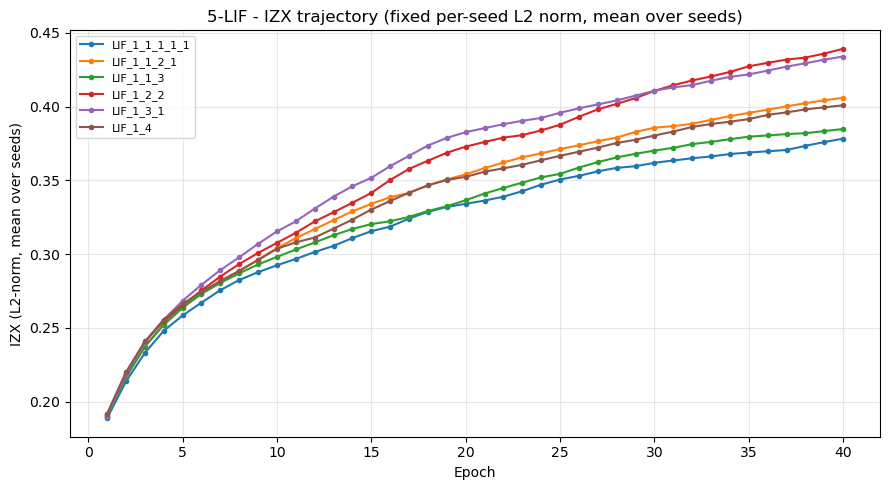

In [10]:
for metric_name, metric_idx in [('IZY', 1), ('IZX', 2)]:
    for group in GROUPS:
        normed = normalize_per_seed_fixed_l2(data[group])
        fig, ax = plt.subplots(figsize=(9, 5))
        for model in sorted(normed.keys()):
            ep_to_vals = defaultdict(list)
            for rows in normed[model].values():
                for ep, izy_n, izx_n in rows:
                    ep_to_vals[ep].append(izy_n if metric_idx == 1 else izx_n)
            eps = sorted(ep_to_vals)
            means = [np.mean(ep_to_vals[e]) for e in eps]
            ax.plot(eps, means, marker='o', markersize=3, label=model)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(f'{metric_name} (L2-norm, mean over seeds)')
        ax.set_title(f'{group} - {metric_name} trajectory (fixed per-seed L2 norm, mean over seeds)')
        ax.legend(loc='best', fontsize=8); ax.grid(alpha=0.3)
        fig.tight_layout(); plt.show()